In [2]:
#Importing LIB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading files
log = pd.read_excel('C:/Machine_Learning/.venv/ML PROJECT/Period_Log.xlsx',engine='openpyxl')
log

user = pd.read_excel('C:/Machine_Learning/.venv/ML PROJECT/User_Profile.xlsx',engine='openpyxl')
user

,user_id,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,Rhode Island,34,26.0,Good,5â€“6 days/week,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00002,New Hampshire,32,26.6,Good,5â€“6 days/week,5.5,2.9,2.3,Weekly,No,0,0,5.7
2,U00003,Iowa,18,16.0,Poor,1â€“2 days/week,6.7,0.5,2.1,Never,No,1,0,3.1
3,U00004,Texas,30,24.7,Excellent,NaN,7.3,0.4,1.8,Occasionally,No,1,0,6.6
4,U00005,Delaware,32,29.2,Good,1â€“2 days/week,7.1,2.2,2.2,Occasionally,No,0,1,3.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,U01996,Tennessee,30,20.0,Average,NaN,8.7,0.1,2.1,Never,No,0,0,7.5
1996,U01997,Utah,30,32.8,Poor,3â€“4 days/week,6.9,1.5,1.3,Occasionally,No,0,0,2.4
1997,U01998,Wisconsin,27,26.1,Good,1â€“2 days/week,9.2,2.1,2.8,Never,No,1,0,6.4
1998,U01999,South Carolina,28,26.5,Good,1â€“2 days/week,4.9,0.0,2.8,Occasionally,No,0,0,6.2


In [3]:
log.dtypes

user_id                           object
cycle_number                       int64
start_date                datetime64[ns]
cycle_length_days                  int64
prev_cycle_length                float64
cycle_phase                       object
flow_level                        object
pain_level                         int64
pms_symptoms                      object
mood_score                         int64
stress_score_cycle               float64
sleep_hours_cycle                float64
energy_level                       int64
concentration_score                int64
work_hours_lost                  float64
estrogen_pgml                    float64
progesterone_ngml                float64
ovulation_result                  object
overall_health_score             float64
log_consistency_score            float64
prepared_before_period             int64
dtype: object

In [4]:
user.dtypes

user_id                   object
state                     object
age                        int64
bmi                      float64
diet_quality              object
exercise_frequency        object
sleep_hours              float64
caffeine_intake          float64
water_intake_liters      float64
alcohol_consumption       object
smoking_status            object
birth_control_use          int64
pcos_diagnosed             int64
stress_score_baseline    float64
dtype: object

In [5]:
log.head()

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,sleep_hours_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,ovulation_result,overall_health_score,log_consistency_score,prepared_before_period
0,U00001,1,2024-02-13,33,NaN,Luteal,Heavy,9,Yes,6,...,5.3,6,7,5.1,84.7,4.14,Positive,6.5,0.949,0
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,4.6,7,8,2.6,126.1,2.79,Negative,9.4,0.949,1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,...,5.1,5,5,6.8,131.1,1.70,Negative,6.7,0.949,1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,...,6.7,8,8,2.5,82.0,8.50,Negative,9.0,0.949,0
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,...,5.8,9,8,2.4,55.5,6.30,Negative,9.3,0.949,1


In [6]:
user.tail()

,user_id,state,age,bmi,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
1995,U01996,Tennessee,30,20.0,Average,NaN,8.7,0.1,2.1,Never,No,0,0,7.5
1996,U01997,Utah,30,32.8,Poor,3â€“4 days/week,6.9,1.5,1.3,Occasionally,No,0,0,2.4
1997,U01998,Wisconsin,27,26.1,Good,1â€“2 days/week,9.2,2.1,2.8,Never,No,1,0,6.4
1998,U01999,South Carolina,28,26.5,Good,1â€“2 days/week,4.9,0.0,2.8,Occasionally,No,0,0,6.2
1999,U02000,Hawaii,24,20.1,Good,1â€“2 days/week,4.9,2.3,2.3,Occasionally,No,1,0,6.7


In [7]:
log.isna().sum()

user_id                      0
cycle_number                 0
start_date                   0
cycle_length_days            0
prev_cycle_length         2000
cycle_phase                  0
flow_level                   0
pain_level                   0
pms_symptoms                 0
mood_score                   0
stress_score_cycle           0
sleep_hours_cycle            0
energy_level                 0
concentration_score          0
work_hours_lost              0
estrogen_pgml                0
progesterone_ngml            0
ovulation_result             0
overall_health_score         0
log_consistency_score        0
prepared_before_period       0
dtype: int64

In [8]:
user.isna().sum()

user_id                    0
state                      0
age                        0
bmi                        0
diet_quality               0
exercise_frequency       385
sleep_hours                0
caffeine_intake            0
water_intake_liters        0
alcohol_consumption        0
smoking_status             0
birth_control_use          0
pcos_diagnosed             0
stress_score_baseline      0
dtype: int64

In [9]:
log['prev_cycle_length'].unique()

array([nan, 33., 34., 31., 37., 32., 25., 27., 30., 28., 24., 26., 29.,
       36., 39., 22., 23., 35., 40., 38., 42., 41., 44.])

In [10]:
#Filling missing values 
log['prev_cycle_length'] = log['prev_cycle_length'].fillna(log['prev_cycle_length'].mode() [0])

In [11]:
user['exercise_frequency'].unique()

array(['5â€“6 days/week', '1â€“2 days/week', nan, '3â€“4 days/week'],
      dtype=object)

In [12]:
user['exercise_frequency']=user['exercise_frequency'].str.replace('â€“','-')
user['exercise_frequency'].unique()

array(['5-6 days/week', '1-2 days/week', nan, '3-4 days/week'],
      dtype=object)

In [13]:
exercise_mapping = {
    '5-6 days/week': 5.5,
    '3-4 days/week': 3.5,
    '1-2 days/week': 1.5
}
user['exercise_frequency'] = user['exercise_frequency'].map(exercise_mapping)

In [14]:
user['exercise_frequency'].unique()

array([5.5, 1.5, nan, 3.5])

In [15]:
user['exercise_frequency'] = user['exercise_frequency'].fillna(user['exercise_frequency'].median())

In [16]:
log.isna().sum()

user_id                   0
cycle_number              0
start_date                0
cycle_length_days         0
prev_cycle_length         0
cycle_phase               0
flow_level                0
pain_level                0
pms_symptoms              0
mood_score                0
stress_score_cycle        0
sleep_hours_cycle         0
energy_level              0
concentration_score       0
work_hours_lost           0
estrogen_pgml             0
progesterone_ngml         0
ovulation_result          0
overall_health_score      0
log_consistency_score     0
prepared_before_period    0
dtype: int64

In [17]:
user.isna().sum()

user_id                  0
state                    0
age                      0
bmi                      0
diet_quality             0
exercise_frequency       0
sleep_hours              0
caffeine_intake          0
water_intake_liters      0
alcohol_consumption      0
smoking_status           0
birth_control_use        0
pcos_diagnosed           0
stress_score_baseline    0
dtype: int64

In [18]:
#merging user and log files
data = pd.merge(log,user,on='user_id',how='left')
data

,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,...,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,U00001,1,2024-02-13,33,28.0,Luteal,Heavy,9,Yes,6,...,Good,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4.1
1,U00001,2,2024-03-17,33,33.0,Follicular,Light,2,No,8,...,Good,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4.1
2,U00001,3,2024-04-19,34,33.0,Follicular,Heavy,8,No,5,...,Good,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4.1
3,U00001,4,2024-05-23,31,34.0,Luteal,Light,3,No,8,...,Good,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4.1
4,U00001,5,2024-06-23,31,31.0,Luteal,Moderate,3,No,9,...,Good,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17971,U02000,6,2024-07-06,26,26.0,Luteal,Moderate,6,No,7,...,Good,1.5,4.9,2.3,2.3,Occasionally,No,1,0,6.7
17972,U02000,7,2024-08-01,27,26.0,Menstrual,Moderate,6,Yes,7,...,Good,1.5,4.9,2.3,2.3,Occasionally,No,1,0,6.7
17973,U02000,8,2024-08-28,30,27.0,Menstrual,Moderate,6,No,5,...,Good,1.5,4.9,2.3,2.3,Occasionally,No,1,0,6.7
17974,U02000,9,2024-09-27,29,30.0,Luteal,Light,3,No,8,...,Good,1.5,4.9,2.3,2.3,Occasionally,No,1,0,6.7


In [19]:
data.columns

Index(['user_id', 'cycle_number', 'start_date', 'cycle_length_days',
       'prev_cycle_length', 'cycle_phase', 'flow_level', 'pain_level',
       'pms_symptoms', 'mood_score', 'stress_score_cycle', 'sleep_hours_cycle',
       'energy_level', 'concentration_score', 'work_hours_lost',
       'estrogen_pgml', 'progesterone_ngml', 'ovulation_result',
       'overall_health_score', 'log_consistency_score',
       'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality',
       'exercise_frequency', 'sleep_hours', 'caffeine_intake',
       'water_intake_liters', 'alcohol_consumption', 'smoking_status',
       'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'],
      dtype='object')

In [20]:
data['cycle_phase'].value_counts()

cycle_phase
Follicular    8092
Luteal        8068
Menstrual     1816
Name: count, dtype: int64

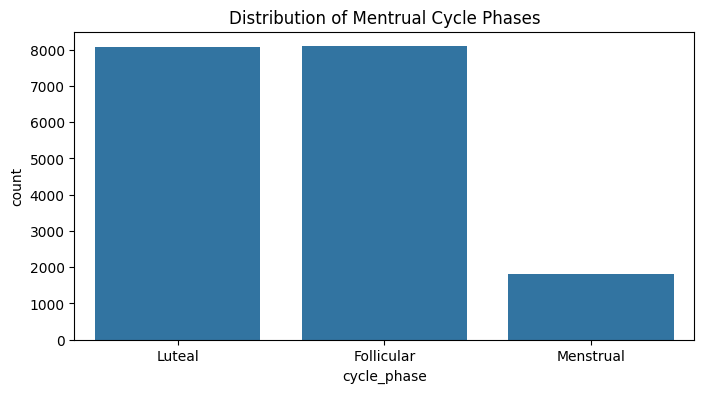

In [21]:
#Cycle Phase Distribution 
plt.figure(figsize=(8,4))
sns.countplot(x='cycle_phase',data=data)
plt.title("Distribution of Mentrual Cycle Phases")
plt.show()

In [22]:
data['flow_level'].value_counts()

flow_level
Moderate    8857
Light       6665
Heavy       2454
Name: count, dtype: int64

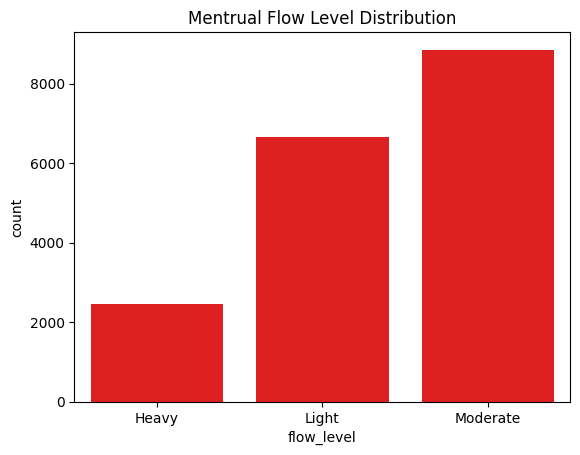

In [23]:
#Flow Level Distribution 
sns.countplot(x='flow_level',data=data,color='r')
plt.title('Mentrual Flow Level Distribution')
plt.show()

In [24]:
data['pms_symptoms'].value_counts()

pms_symptoms
No     12675
Yes     5301
Name: count, dtype: int64

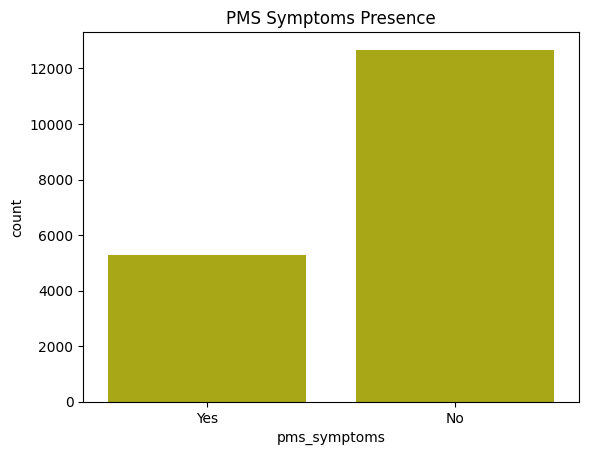

In [25]:
#PMS Symptoms
sns.countplot(x='pms_symptoms', data=data,color='y')
plt.title("PMS Symptoms Presence")
plt.show()

In [26]:
data['ovulation_result'].value_counts()

ovulation_result
Positive    9730
Negative    8246
Name: count, dtype: int64

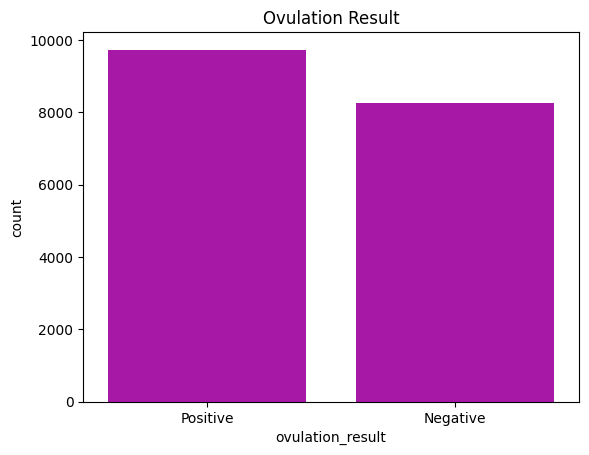

In [27]:
#Ovulation Result
sns.countplot(x='ovulation_result', data=data,color='m')
plt.title("Ovulation Result")
plt.show()

In [28]:
data['diet_quality'].value_counts()

diet_quality
Good         8458
Average      6116
Poor         1744
Excellent    1658
Name: count, dtype: int64

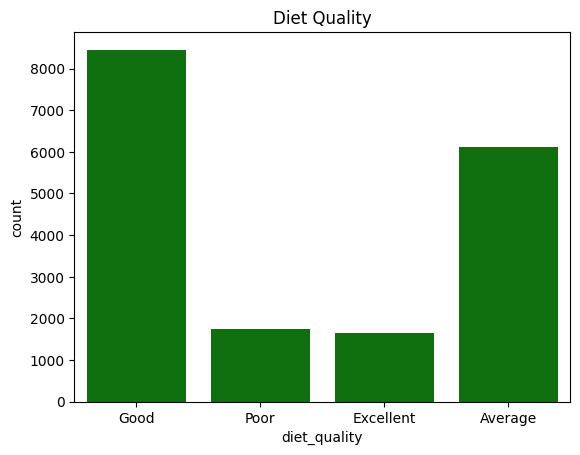

In [29]:
#Diet Quality
sns.countplot(x='diet_quality', data=data,color='g')
plt.title("Diet Quality")
plt.show()

In [30]:
data['alcohol_consumption'].value_counts()

alcohol_consumption
Never           8286
Occasionally    7836
Weekly          1854
Name: count, dtype: int64

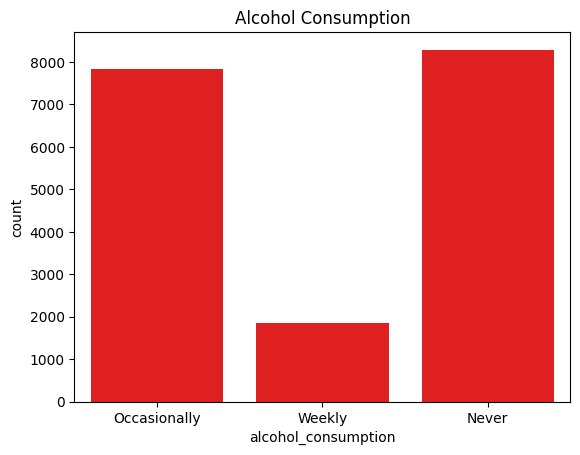

In [31]:
#Alcohol Consumption
sns.countplot(x='alcohol_consumption', data=data,color='r')
plt.title("Alcohol Consumption")
plt.show()

In [32]:
data['smoking_status'].value_counts()

smoking_status
No     16015
Yes     1961
Name: count, dtype: int64

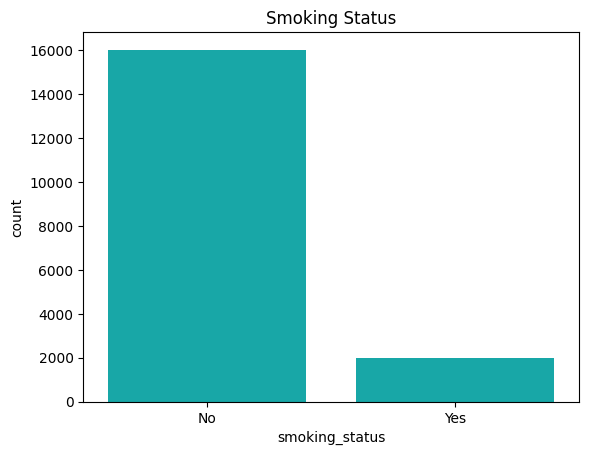

In [33]:
#Smoking Status
sns.countplot(x='smoking_status', data=data,color='c')
plt.title("Smoking Status")
plt.show()

In [34]:
#Energy Level
data['energy_level'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

energy_level
1        5
2       64
3      358
4     1169
5     2355
6     3511
7     4089
8     3410
9     1962
10    1053
Name: count, dtype: int64

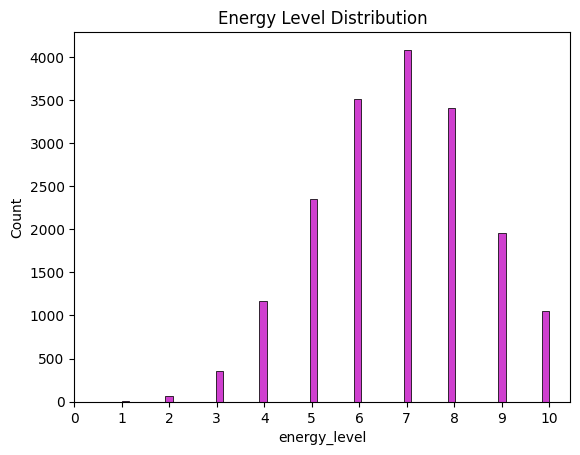

In [35]:
#Energy Level
sns.histplot(data['energy_level'],color='m')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.title("Energy Level Distribution")
plt.show()

In [36]:
#Mood Score
data['mood_score'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

mood_score
1        1
2       11
3      125
4      625
5     1911
6     3529
7     4677
8     3912
9     2153
10    1032
Name: count, dtype: int64

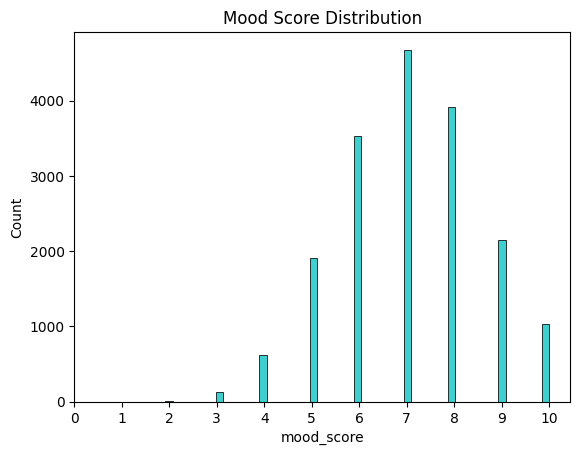

In [37]:
#Mood Score 
sns.histplot(data['mood_score'],color='c')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10])
plt.title("Mood Score Distribution")
plt.show()


In [38]:
#Concentration Score
data['concentration_score'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

concentration_score
2        3
3       39
4      364
5     1391
6     3225
7     4567
8     4406
9     2751
10    1230
Name: count, dtype: int64

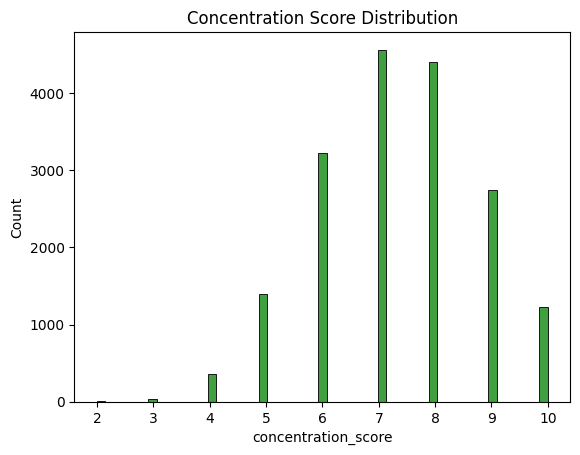

In [39]:
#Concentration Score
sns.histplot(data['concentration_score'],color='g')
plt.title("Concentration Score Distribution")
plt.show()


In [40]:
#Estrogen Level
data['estrogen_pgml'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

estrogen_pgml
10.0     2
15.6     1
20.2     1
22.6     1
22.8     1
        ..
197.5    1
198.1    2
198.2    1
200.6    1
206.5    1
Name: count, Length: 1470, dtype: int64

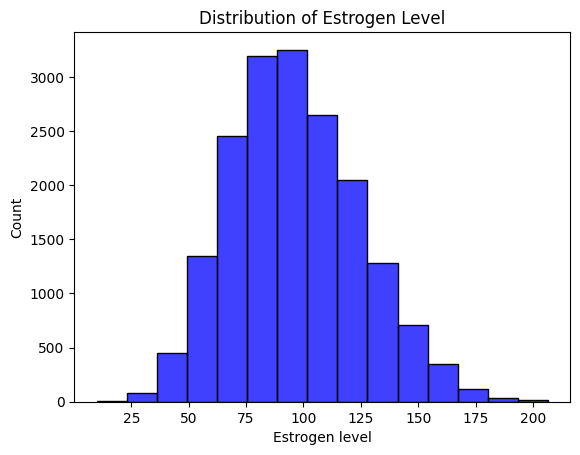

In [41]:
#Estrogen Level Count
sns.histplot(
    data['estrogen_pgml'],
    bins=15,
    kde=False,
    color='b'
)
plt.title("Distribution of Estrogen Level")
plt.xlabel("Estrogen level")
plt.ylabel("Count")
plt.show()


In [42]:
#Progestron Level
data['progesterone_ngml'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

progesterone_ngml
0.10     40
0.11      2
0.13      1
0.14      4
0.15      1
         ..
17.89     2
18.06     1
18.07     2
19.23     1
20.25     1
Name: count, Length: 1554, dtype: int64

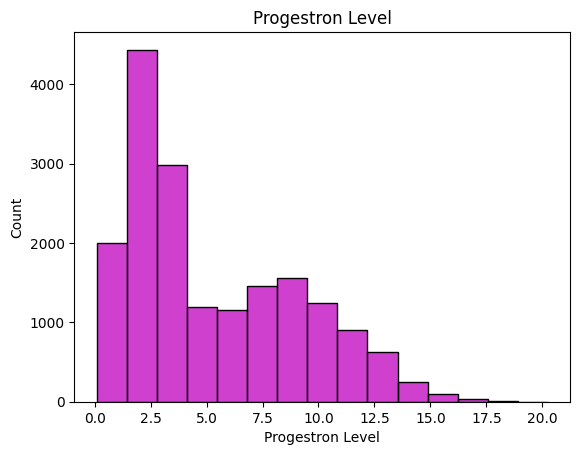

In [43]:
#Progestron Level Count
sns.histplot(
    data['progesterone_ngml'],
    bins=15,
    kde=False,
    color='m'
)
plt.title("Progestron Level")
plt.xlabel("Progestron Level")
plt.ylabel("Count")
plt.show()


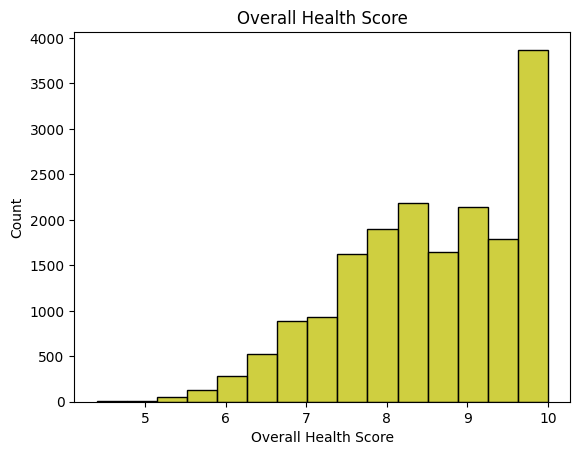

In [44]:
#Overall Health Score
sns.histplot(
    data['overall_health_score'],
    bins=15,
    kde=False,
    color='y'
)
plt.title("Overall Health Score")
plt.xlabel("Overall Health Score")
plt.ylabel("Count")
plt.show()

In [45]:
#Sleep Hours
data['sleep_hours'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

sleep_hours
4.5     419
4.6     115
4.7     119
4.8      84
4.9     139
5.0     136
5.1     168
5.2     162
5.3     224
5.4     226
5.5     322
5.6     386
5.7     417
5.8     238
5.9     374
6.0     525
6.1     368
6.2     429
6.3     404
6.4     456
6.5     690
6.6     591
6.7     577
6.8     576
6.9     661
7.0     526
7.1     655
7.2     550
7.3     607
7.4     506
7.5     533
7.6     516
7.7     520
7.8     377
7.9     464
8.0     450
8.1     462
8.2     373
8.3     355
8.4     383
8.5     213
8.6     228
8.7     169
8.8     144
8.9     153
9.0     156
9.1     148
9.2     100
9.3     125
9.4      83
9.5      51
9.6      70
9.7      50
9.8      28
9.9      25
10.0    150
Name: count, dtype: int64

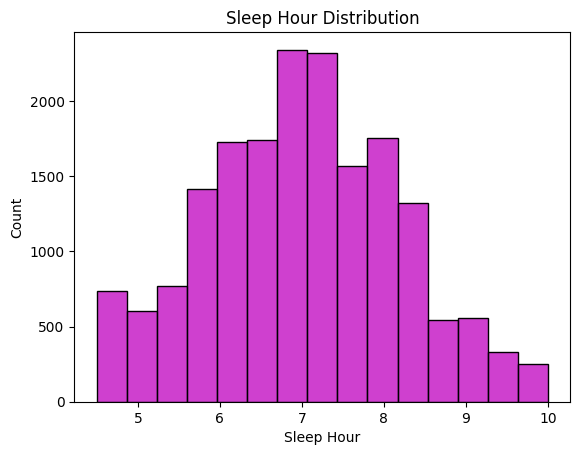

In [46]:
#Sleep Hours
sns.histplot(
    data['sleep_hours'],
    bins=15,
    kde=False,
    color='m'
)
plt.title("Sleep Hour Distribution")
plt.xlabel("Sleep Hour")
plt.ylabel("Count")
plt.show()

In [47]:
#PCOS Diagnosed
pcos_count=data['pcos_diagnosed'].value_counts().sort_values(ascending=True).sort_index(ascending=True)

In [48]:
label = ['No PCOS','PCOS']

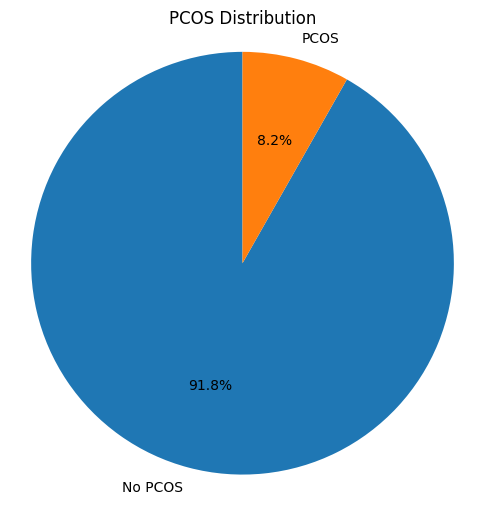

In [49]:
#PCOS Diagnosed
plt.figure(figsize=(6,6))
plt.pie(
    pcos_count.values,labels = label,autopct='%1.1f%%',
    startangle=90
)
plt.title('PCOS Distribution')
plt.axis('equal')
plt.show()


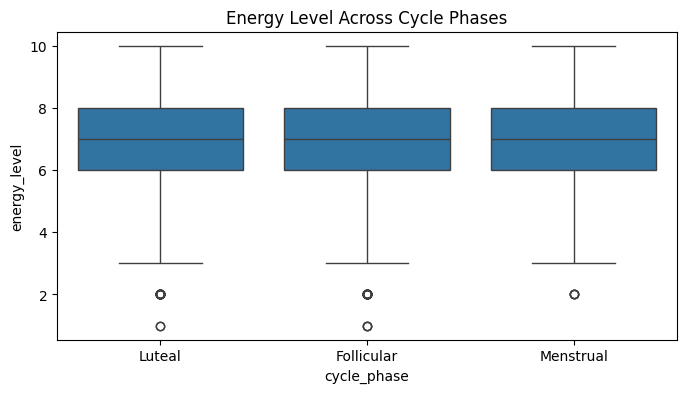

In [50]:
#Cycle Phase vs Energy level 
plt.figure(figsize=(8,4))
sns.boxplot(x='cycle_phase', y='energy_level', data=data)
plt.title("Energy Level Across Cycle Phases")
plt.show()

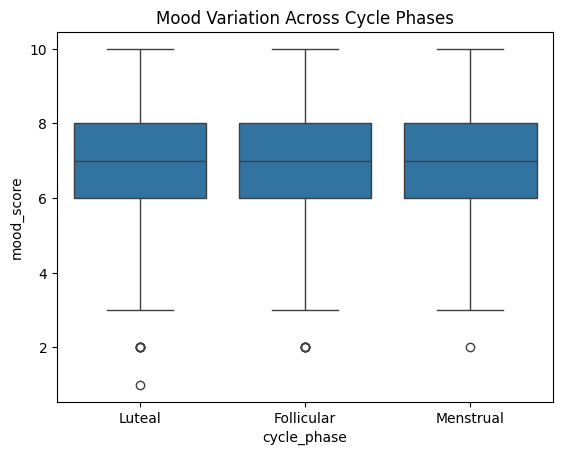

In [51]:
#Cycle Phase vs Mood
sns.boxplot(x='cycle_phase', y='mood_score', data=data)
plt.title("Mood Variation Across Cycle Phases")
plt.show()

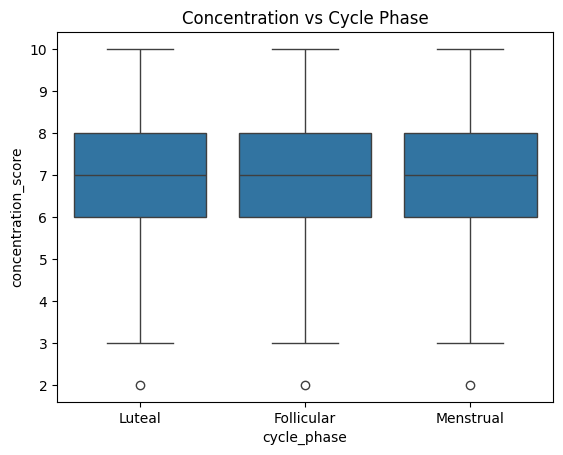

In [52]:
#Cycle phase vs Concentration
sns.boxplot(x='cycle_phase', y='concentration_score', data=data)
plt.title("Concentration vs Cycle Phase")
plt.show()

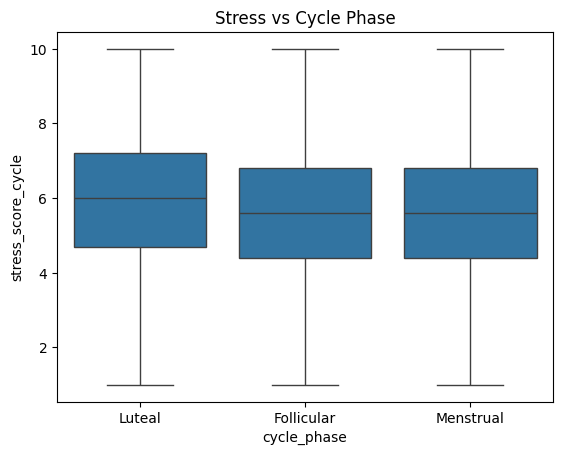

In [53]:
#Cycle phase vs Concentration
sns.boxplot(x='cycle_phase', y='stress_score_cycle', data=data)
plt.title("Stress vs Cycle Phase")
plt.show()

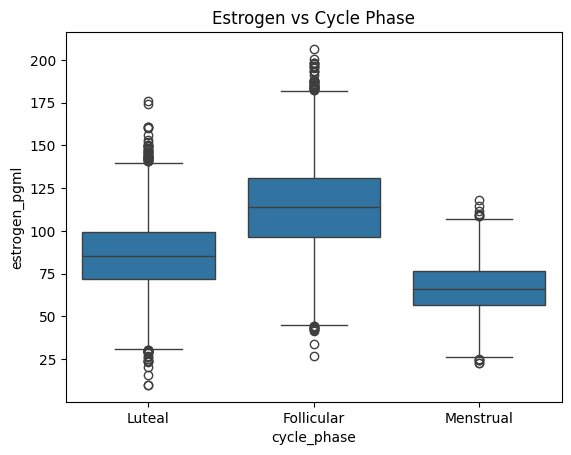

In [54]:
#Cycle phase vs Estrogen Level
sns.boxplot(x='cycle_phase', y='estrogen_pgml', data=data)
plt.title("Estrogen vs Cycle Phase")
plt.show()

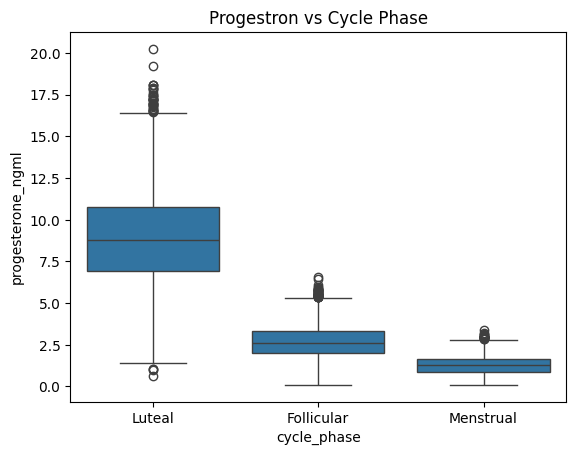

In [55]:
#Cycle phase vs Progestron Level
sns.boxplot(x='cycle_phase', y='progesterone_ngml', data=data)
plt.title("Progestron vs Cycle Phase")
plt.show()

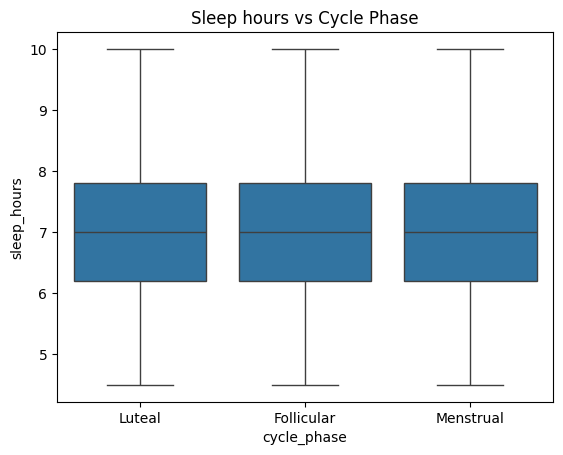

In [56]:
#Cycle phase vs Sleep Hours
sns.boxplot(x='cycle_phase', y='sleep_hours', data=data)
plt.title("Sleep hours vs Cycle Phase")
plt.show()

In [57]:
data.drop(['user_id','state','stress_score_baseline','sleep_hours_cycle'],axis=1,inplace=True)

In [58]:
data['month'] = data['start_date'].dt.month

In [59]:
data['day_of_week'] = data['start_date'].dt.day_of_week

In [60]:
data.drop(['start_date'],axis=1,inplace=True)

In [61]:
data.head()

,cycle_number,cycle_length_days,prev_cycle_length,cycle_phase,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,...,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,month,day_of_week
0,1,33,28.0,Luteal,Heavy,9,Yes,6,5.4,6,...,5.5,5.4,1.5,2.0,Occasionally,No,1,1,2,1
1,2,33,33.0,Follicular,Light,2,No,8,3.7,7,...,5.5,5.4,1.5,2.0,Occasionally,No,1,1,3,6
2,3,34,33.0,Follicular,Heavy,8,No,5,5.7,5,...,5.5,5.4,1.5,2.0,Occasionally,No,1,1,4,4
3,4,31,34.0,Luteal,Light,3,No,8,5.2,8,...,5.5,5.4,1.5,2.0,Occasionally,No,1,1,5,3
4,5,31,31.0,Luteal,Moderate,3,No,9,3.7,9,...,5.5,5.4,1.5,2.0,Occasionally,No,1,1,6,6


In [62]:
#Encoding Flow Level 
flow_map = {'Light':1,'Moderate': 2, 'Heavy': 3}
data['flow_level'] = data['flow_level'].map(flow_map)

In [63]:
#Encoding Deit Quality
diet_map = {'Poor': 1,'Fair': 2, 'Good': 3, 'Excellent': 4}
data['diet_quality'] = data['diet_quality'].map(diet_map)

In [64]:
data['pms_symptoms'] = data['pms_symptoms'].map({'Yes':1,'No':0})

In [65]:
#Encoding Alcohol Consumption
alcohol_map = {'Never': 1,'Weekly': 2, 'Occasionally': 3}
data['alcohol_consumption'] = data['alcohol_consumption'].map(alcohol_map)

In [66]:
data = pd.get_dummies(data,columns=['cycle_phase','ovulation_result','smoking_status'],dtype=int)

In [67]:
data.head()

,cycle_number,cycle_length_days,prev_cycle_length,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,...,pcos_diagnosed,month,day_of_week,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,smoking_status_No,smoking_status_Yes
0,1,33,28.0,3,9,1,6,5.4,6,7,...,1,2,1,0,1,0,0,1,1,0
1,2,33,33.0,1,2,0,8,3.7,7,8,...,1,3,6,1,0,0,1,0,1,0
2,3,34,33.0,3,8,0,5,5.7,5,5,...,1,4,4,1,0,0,1,0,1,0
3,4,31,34.0,1,3,0,8,5.2,8,8,...,1,5,3,0,1,0,1,0,1,0
4,5,31,31.0,2,3,0,9,3.7,9,8,...,1,6,6,0,1,0,1,0,1,0


In [68]:
#Correlation 
corr = data.corr()
corr

,cycle_number,cycle_length_days,prev_cycle_length,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,...,pcos_diagnosed,month,day_of_week,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,smoking_status_No,smoking_status_Yes
cycle_number,1.000000,0.004552,-0.001105,0.004478,-0.003029,-0.005322,0.010633,-0.008585,0.006503,0.013668,...,0.002243,0.897006,-0.006033,0.025273,-0.016001,-0.015313,-0.002955,0.002955,-0.012035,0.012035
cycle_length_days,0.004552,1.000000,0.260845,0.038639,0.060488,-0.004504,-0.029697,-0.012828,-0.027576,-0.032034,...,0.373661,0.019582,0.000251,-0.019015,0.013952,0.008365,0.043769,-0.043769,-0.022626,0.022626
prev_cycle_length,-0.001105,0.260845,1.000000,0.027705,0.052207,-0.003144,-0.020318,-0.020761,-0.017601,-0.024708,...,0.351906,0.029866,-0.016778,0.007517,-0.002548,-0.008204,0.040445,-0.040445,-0.020481,0.020481
flow_level,0.004478,0.038639,0.027705,1.000000,0.603925,0.056915,-0.308686,0.023802,-0.322632,-0.328904,...,0.101533,0.000025,0.005614,-0.003058,0.003988,-0.001534,-0.053000,0.053000,-0.012569,0.012569
pain_level,-0.003029,0.060488,0.052207,0.603925,1.000000,0.120695,-0.646025,0.607297,-0.706613,-0.727485,...,0.183338,-0.004489,0.001851,-0.050908,0.063747,-0.021166,-0.021574,0.021574,-0.020353,0.020353
pms_symptoms,-0.005322,-0.004504,-0.003144,0.056915,0.120695,1.000000,-0.099961,0.157259,-0.116634,-0.118263,...,0.004063,-0.007860,-0.000416,-0.012083,0.014914,-0.004666,0.001055,-0.001055,-0.004584,0.004584
mood_score,0.010633,-0.029697,-0.020318,-0.308686,-0.646025,-0.099961,1.000000,-0.538454,0.501656,0.512416,...,-0.096195,0.012645,-0.001828,0.046586,-0.056455,0.016266,0.013305,-0.013305,0.019377,-0.019377
stress_score_cycle,-0.008585,-0.012828,-0.020761,0.023802,0.607297,0.157259,-0.538454,1.000000,-0.628511,-0.631957,...,-0.009018,-0.011871,0.005615,-0.080050,0.098539,-0.030478,0.000492,-0.000492,-0.014582,0.014582
energy_level,0.006503,-0.027576,-0.017601,-0.322632,-0.706613,-0.116634,0.501656,-0.628511,1.000000,0.574715,...,-0.086398,0.007709,-0.000493,0.051692,-0.063755,0.019886,0.010980,-0.010980,0.005697,-0.005697
concentration_score,0.013668,-0.032034,-0.024708,-0.328904,-0.727485,-0.118263,0.512416,-0.631957,0.574715,1.000000,...,-0.102496,0.017314,-0.007110,0.055824,-0.067353,0.019003,0.007562,-0.007562,0.013470,-0.013470


In [69]:
#Correlation Matrix
groups = {
    "A_Cycle_Physical_Symptoms": [
        'flow_level',
        'pain_level',
        'pms_symptoms',
        'prev_cycle_length',
        'cycle_length_days',
        'cycle_number'
    ],

    "B_Mental_Productivity_Core": [
        'mood_score',
        'stress_score_cycle',
        'energy_level',
        'concentration_score',
        'sleep_hours',
        'overall_health_score'
    ],

    "C_Work_Impact": [
        'work_hours_lost',
        'pain_level',
        'stress_score_cycle',
        'mood_score',
        'energy_level'
    ],

    "D_Hormones": [
        'estrogen_pgml',
        'progesterone_ngml'
    ],

    "E_Cycle_Phase": [
        'cycle_phase_Luteal',
        'cycle_phase_Menstrual',
        'ovulation_result_Positive'
    ],

    "F_Lifestyle_Demographics": [
        'age',
        'bmi',
        'diet_quality',
        'exercise_frequency',
        'water_intake_liters',
        'caffeine_intake',
        'alcohol_consumption'
    ],

    "G_Medical_Conditions": [
        'pcos_diagnosed',
        'birth_control_use',
        'smoking_status_Yes'
    ]
}


In [70]:
def plot_group_correlation(data, features, title):
    corr = data[features].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        cbar=True
    )

    plt.title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

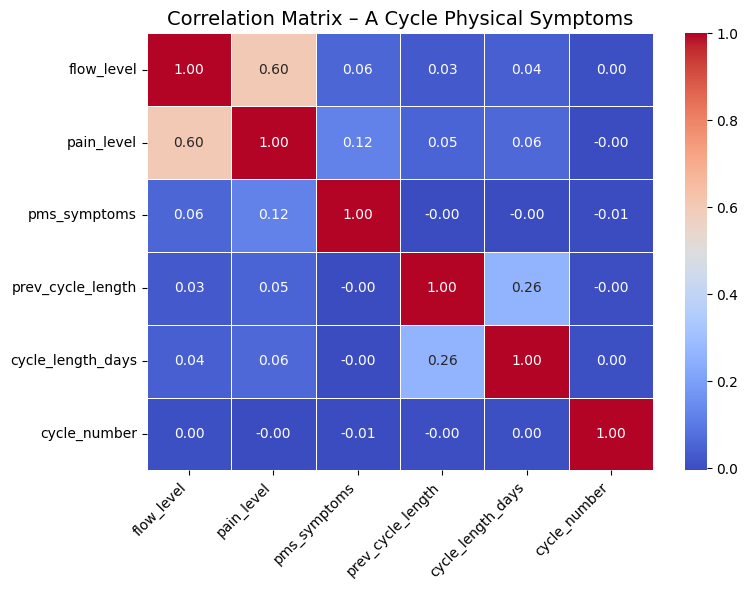

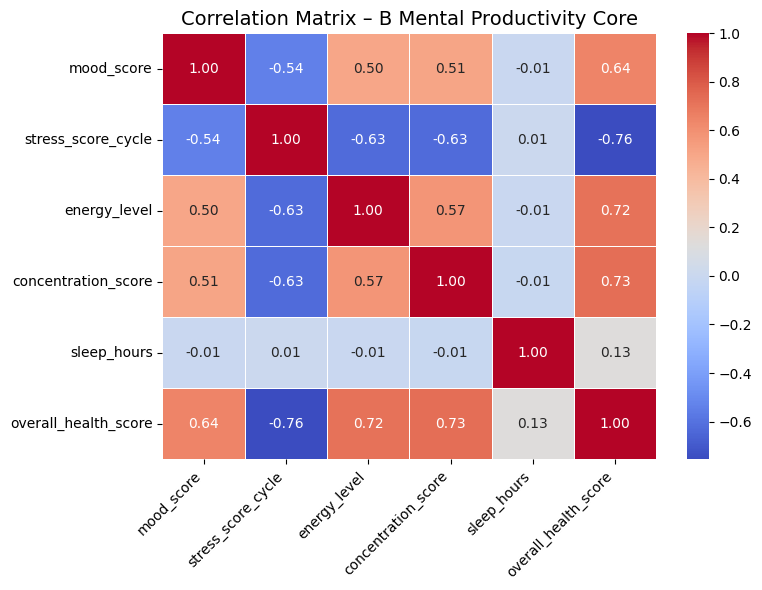

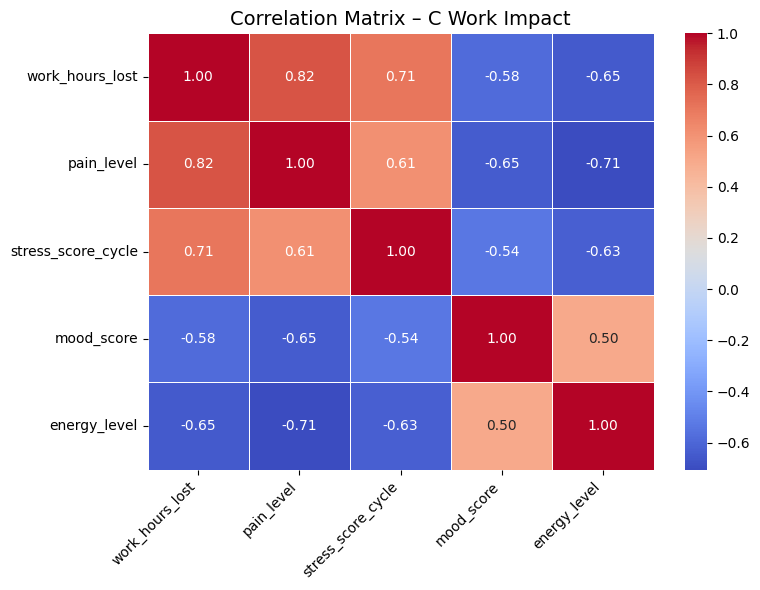

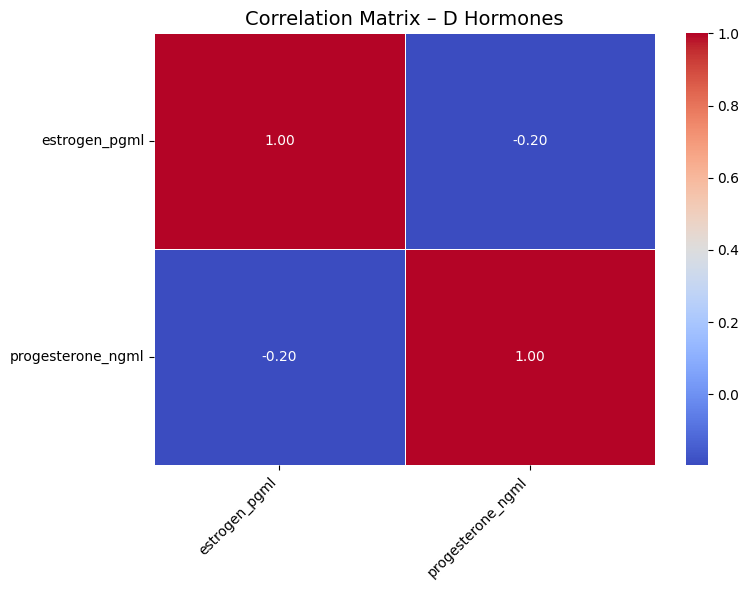

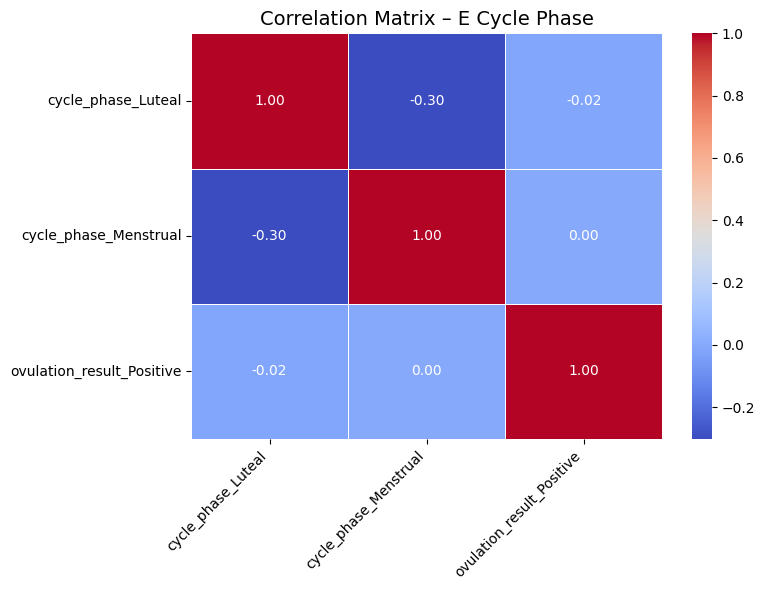

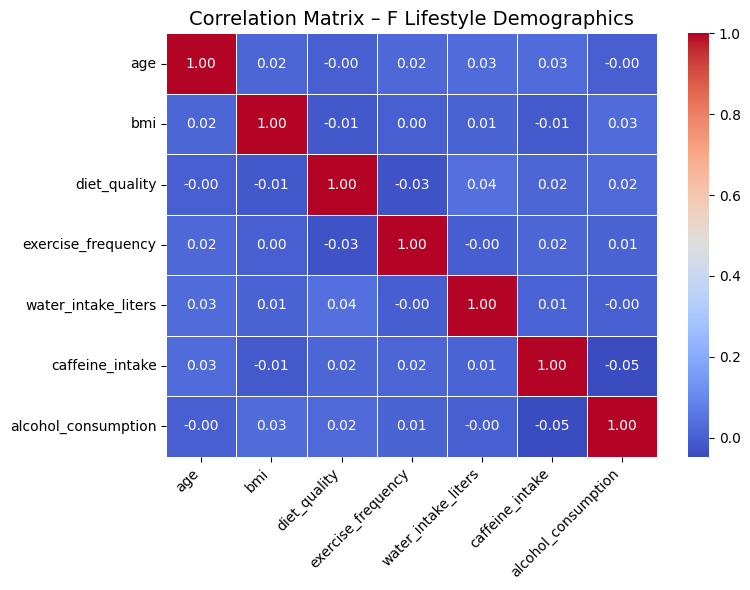

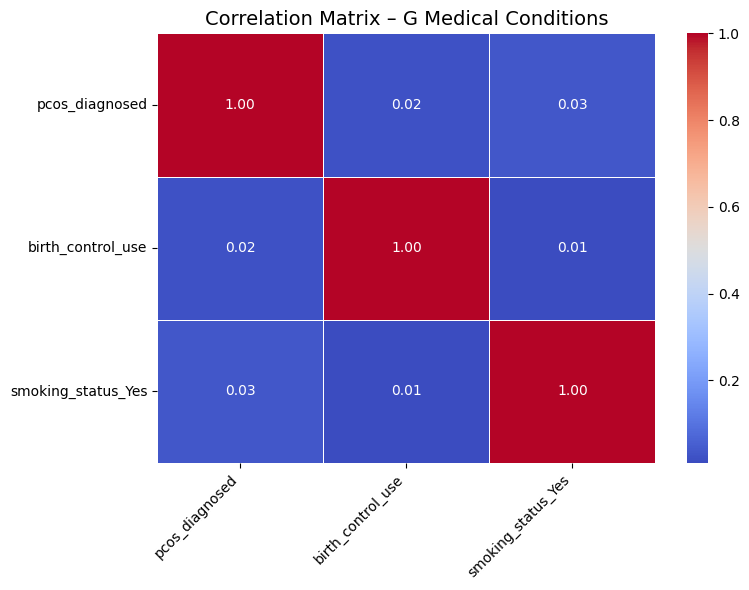

In [71]:
for group_name, feature_list in groups.items():
    plot_group_correlation(
        data,
        feature_list,
        title=f"Correlation Matrix – {group_name.replace('_', ' ')}"
    )

In [72]:
#Overall Health score is a composite variable, it already summarizes mood energy concentration. 
#Drop Overall Health Score , work hour lost,smoking status, birth control use *

#Zero Coorelation 
#Age Bmi deit quality exercise frequency water intake alcohol consumption 

#Redunant Features 
#cycle number , prev cycle length 

#keep - cycle length days, pain level 

In [73]:
cluster_features = ['mood_score','energy_level','concentration_score',
                    'stress_score_cycle','sleep_hours','pain_level',
                    'flow_level','estrogen_pgml','progesterone_ngml']

In [74]:
#Scaling 
from sklearn.preprocessing import StandardScaler
X = data[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [75]:
#clustering - Elbow Method 
from sklearn.cluster import KMeans
wcss=[] #[s1...s10]
for i in range(1,11):#k=1....10
    kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42) #init - kmeans initialization
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) #variance

In [76]:
wcss

[161783.99999999983,
 118104.94686858651,
 106959.0787896589,
 98498.8418270046,
 94314.12050114441,
 88790.79660189347,
 86142.83660874204,
 82552.12599855129,
 79498.38600668423,
 77447.78437110179]

Text(0.5, 1.0, 'Elbow points')

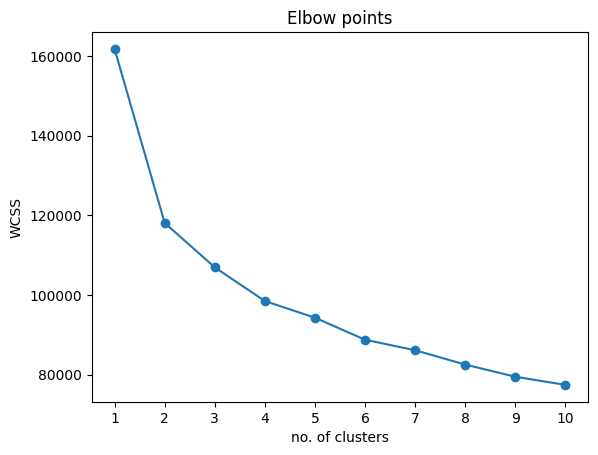

In [77]:
plt.plot(range(1,11),wcss,marker='o')
plt.xticks([1,2,3,4,5,6,7,8,9,10])
plt.xlabel('no. of clusters')
plt.ylabel('WCSS')
plt.title('Elbow points')

In [78]:
#After k=3,4 the curve flattens. Therefore the best elbow point is at k = 3
#Number of Clusters = 3
#Using elbow method, the optimal number of clusters is selected as 3 since after 
#k=3 the decrease in WCSS become marginal indicating diminishing returns from 
#adding more clusters.

In [79]:
kmeans = KMeans(n_clusters=3,random_state=42)
data['productivity_cluster'] = kmeans.fit_predict(X)
data


,cycle_number,cycle_length_days,prev_cycle_length,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,...,month,day_of_week,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,smoking_status_No,smoking_status_Yes,productivity_cluster
0,1,33,28.0,3,9,1,6,5.4,6,7,...,2,1,0,1,0,0,1,1,0,2
1,2,33,33.0,1,2,0,8,3.7,7,8,...,3,6,1,0,0,1,0,1,0,1
2,3,34,33.0,3,8,0,5,5.7,5,5,...,4,4,1,0,0,1,0,1,0,1
3,4,31,34.0,1,3,0,8,5.2,8,8,...,5,3,0,1,0,1,0,1,0,0
4,5,31,31.0,2,3,0,9,3.7,9,8,...,6,6,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17971,6,26,26.0,2,6,0,7,6.0,6,7,...,7,5,0,1,0,1,0,1,0,0
17972,7,27,26.0,2,6,1,7,8.2,8,6,...,8,3,0,0,1,0,1,1,0,0
17973,8,30,27.0,2,6,0,5,7.6,6,7,...,8,2,0,0,1,1,0,1,0,0
17974,9,29,30.0,1,3,0,8,7.2,6,8,...,9,4,0,1,0,0,1,1,0,2


In [80]:
data['productivity_cluster'].value_counts()

productivity_cluster
2    7760
0    6063
1    4153
Name: count, dtype: int64

In [81]:
#cluster_map = {
#    0: 'High',
#    1: 'Medium',
#    2: 'Low'
#}

#data['productivity_label'] = data['productivity_cluster'].map(cluster_map)

In [82]:
data.head()

,cycle_number,cycle_length_days,prev_cycle_length,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,...,month,day_of_week,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,smoking_status_No,smoking_status_Yes,productivity_cluster
0,1,33,28.0,3,9,1,6,5.4,6,7,...,2,1,0,1,0,0,1,1,0,2
1,2,33,33.0,1,2,0,8,3.7,7,8,...,3,6,1,0,0,1,0,1,0,1
2,3,34,33.0,3,8,0,5,5.7,5,5,...,4,4,1,0,0,1,0,1,0,1
3,4,31,34.0,1,3,0,8,5.2,8,8,...,5,3,0,1,0,1,0,1,0,0
4,5,31,31.0,2,3,0,9,3.7,9,8,...,6,6,0,1,0,1,0,1,0,0


In [83]:
data.drop(['cycle_number','prev_cycle_length','overall_health_score',
         'age','bmi','exercise_frequency',
        'water_intake_liters','caffeine_intake',
          'alcohol_consumption','birth_control_use',
        'smoking_status_Yes','smoking_status_No'],axis=1,inplace=True)



In [84]:
data.drop(['month','day_of_week'],axis=1,inplace=True)

In [85]:
data.head()

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,...,prepared_before_period,diet_quality,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,productivity_cluster
0,33,3,9,1,6,5.4,6,7,5.1,84.7,...,0,3.0,5.4,1,0,1,0,0,1,2
1,33,1,2,0,8,3.7,7,8,2.6,126.1,...,1,3.0,5.4,1,1,0,0,1,0,1
2,34,3,8,0,5,5.7,5,5,6.8,131.1,...,1,3.0,5.4,1,1,0,0,1,0,1
3,31,1,3,0,8,5.2,8,8,2.5,82.0,...,0,3.0,5.4,1,0,1,0,1,0,0
4,31,2,3,0,9,3.7,9,8,2.4,55.5,...,1,3.0,5.4,1,0,1,0,1,0,0


In [159]:
data.tail()

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,diet_quality,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive,productivity_cluster
17971,26,2,6,0,7,6.0,6,7,5.3,77.5,5.31,3.0,4.9,0,0,1,0,1,0,0
17972,27,2,6,1,7,8.2,8,6,3.0,65.5,0.74,3.0,4.9,0,0,0,1,0,1,0
17973,30,2,6,0,5,7.6,6,7,4.6,51.9,1.26,3.0,4.9,0,0,0,1,1,0,0
17974,29,1,3,0,8,7.2,6,8,3.0,85.3,8.99,3.0,4.9,0,0,1,0,0,1,2
17975,27,2,4,1,8,6.8,7,9,3.7,109.1,2.17,3.0,4.9,0,1,0,0,1,0,2


In [86]:
x = data.drop(['productivity_cluster','diet_quality'],axis=1)
y = data['productivity_cluster']

In [134]:
x

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive
0,33,3,9,1,6,5.4,6,7,5.1,84.7,4.14,5.4,1,0,1,0,0,1
1,33,1,2,0,8,3.7,7,8,2.6,126.1,2.79,5.4,1,1,0,0,1,0
2,34,3,8,0,5,5.7,5,5,6.8,131.1,1.70,5.4,1,1,0,0,1,0
3,31,1,3,0,8,5.2,8,8,2.5,82.0,8.50,5.4,1,0,1,0,1,0
4,31,2,3,0,9,3.7,9,8,2.4,55.5,6.30,5.4,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17971,26,2,6,0,7,6.0,6,7,5.3,77.5,5.31,4.9,0,0,1,0,1,0
17972,27,2,6,1,7,8.2,8,6,3.0,65.5,0.74,4.9,0,0,0,1,0,1
17973,30,2,6,0,5,7.6,6,7,4.6,51.9,1.26,4.9,0,0,0,1,1,0
17974,29,1,3,0,8,7.2,6,8,3.0,85.3,8.99,4.9,0,0,1,0,0,1


In [135]:
y

0        2
1        1
2        1
3        0
4        0
        ..
17971    0
17972    0
17973    0
17974    2
17975    2
Name: productivity_cluster, Length: 17976, dtype: int32

In [89]:
#data = data.drop(columns=['diet_quality'],axis=1,inplace=True)


In [136]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)
x_train

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive
9186,27,2,4,0,9,4.8,8,8,3.7,91.4,8.95,6.2,0,0,1,0,0,1
4467,28,1,3,1,7,5.3,8,8,1.9,88.5,3.77,9.0,0,1,0,0,0,1
14834,27,2,4,1,7,3.8,10,9,2.6,150.6,2.97,6.3,0,1,0,0,1,0
9348,25,1,2,0,8,4.6,9,9,2.1,70.6,8.42,6.8,0,0,1,0,1,0
3891,24,1,4,0,7,5.2,5,8,3.3,76.8,7.38,6.4,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,27,2,3,1,8,5.3,9,7,1.8,128.9,2.19,6.8,0,1,0,0,1,0
17289,28,2,5,0,5,8.1,8,5,3.9,86.5,2.64,7.9,0,0,1,0,1,0
5192,28,1,5,0,4,8.1,4,6,4.3,118.1,1.98,6.0,0,1,0,0,0,1
12172,30,3,5,0,7,2.5,9,7,3.2,94.1,10.66,7.2,0,0,1,0,0,1


In [148]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [149]:
x_train

array([[-0.33689014,  0.35459006, -0.37722272, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.08062949, -1.133736  , -0.82430611, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [-0.33689014,  0.35459006, -0.37722272, ..., -0.33539001,
         1.08587202, -1.08587202],
       ...,
       [ 0.08062949, -1.133736  ,  0.06986067, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.91566875,  1.84291612,  0.06986067, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.08062949,  0.35459006, -0.37722272, ..., -0.33539001,
         1.08587202, -1.08587202]], shape=(14380, 18))

In [139]:
x_train

array([[-0.33689014,  0.35459006, -0.37722272, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.08062949, -1.133736  , -0.82430611, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [-0.33689014,  0.35459006, -0.37722272, ..., -0.33539001,
         1.08587202, -1.08587202],
       ...,
       [ 0.08062949, -1.133736  ,  0.06986067, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.91566875,  1.84291612,  0.06986067, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.08062949,  0.35459006, -0.37722272, ..., -0.33539001,
         1.08587202, -1.08587202]], shape=(14380, 18))

In [140]:
x_test

array([[-0.75440978,  0.35459006,  0.96402744, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 1.33318838, -1.133736  , -0.37722272, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [ 0.49814912, -1.133736  , -0.37722272, ..., -0.33539001,
         1.08587202, -1.08587202],
       ...,
       [ 0.91566875,  0.35459006,  0.51694405, ..., -0.33539001,
         1.08587202, -1.08587202],
       [-0.75440978, -1.133736  , -0.37722272, ..., -0.33539001,
        -0.92091884,  0.92091884],
       [-0.33689014,  0.35459006,  0.96402744, ..., -0.33539001,
        -0.92091884,  0.92091884]], shape=(3596, 18))

In [141]:
y_test

15692    2
8676     2
15809    2
4939     1
6793     0
        ..
4237     0
415      0
3203     1
1890     1
9838     1
Name: productivity_cluster, Length: 3596, dtype: int32

In [142]:
y_train

9186     2
4467     2
14834    1
9348     0
3891     0
        ..
10955    1
17289    2
5192     1
12172    2
235      2
Name: productivity_cluster, Length: 14380, dtype: int32

In [97]:
len(x_train)

14380

In [98]:
len(y_train)

14380

In [99]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred_knn = knn.predict(x_test)
y_pred_knn

array([2, 0, 2, ..., 1, 2, 1], shape=(3596,), dtype=int32)

In [100]:
from sklearn.metrics import accuracy_score
ac_knn = accuracy_score(y_pred_knn,y_test)
ac_knn

0.7369299221357063

In [101]:
from sklearn.naive_bayes import GaussianNB
naive = GaussianNB()
naive.fit(x_train,y_train)
y_pred_naive = naive.predict(x_test)
y_pred_naive

array([1, 2, 2, ..., 1, 1, 1], shape=(3596,), dtype=int32)

In [102]:
from sklearn.metrics import accuracy_score
ac_naive = accuracy_score(y_pred_naive,y_test)
ac_naive

0.681868743047831

In [103]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(x_train,y_train)
y_pred_svm = svm.predict(x_test)
y_pred_svm

array([2, 2, 2, ..., 1, 1, 1], shape=(3596,), dtype=int32)

In [104]:
from sklearn.metrics import accuracy_score
ac_svm = accuracy_score(y_pred_svm,y_test)
ac_svm

0.9688542825361512

In [105]:
from sklearn.tree import DecisionTreeClassifier
model_DT=DecisionTreeClassifier(criterion='entropy')
model_DT.fit(x_train,y_train)
y_pred_tree=model_DT.predict(x_test)
y_pred_tree

array([2, 2, 2, ..., 1, 1, 1], shape=(3596,), dtype=int32)

In [106]:
ac_tree=accuracy_score(y_pred_tree,y_test)
ac_tree

0.9977753058954394

In [151]:
from sklearn.ensemble import RandomForestClassifier
model_RT=RandomForestClassifier(n_estimators=100)
model_RT.fit(x_train,y_train)
y_pred_random=model_RT.predict(x_test)
y_pred_random

array([2, 2, 2, ..., 1, 1, 1], shape=(3596,), dtype=int32)

In [152]:
ac_random=accuracy_score(y_pred_random,y_test)
ac_random

0.9988876529477196

Text(0, 0.5, 'Score')

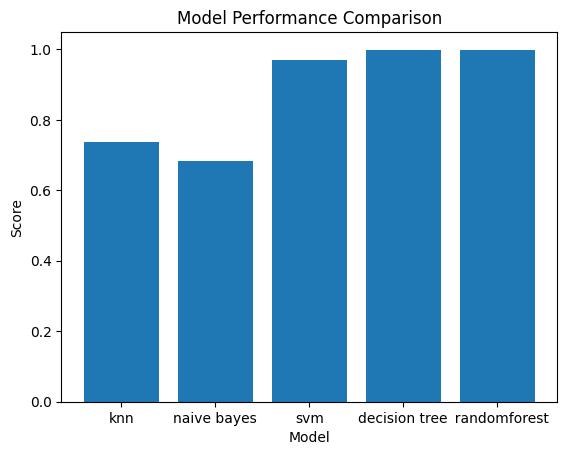

In [153]:
sc={"knn":[ac_knn],"naive bayes":[ac_naive],"svm":[ac_svm],"decision tree":[ac_tree],"  randomforest":[ac_random]}
k=pd.DataFrame(sc)
plt.bar(k.keys(),k.values[0])
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')

In [110]:
#Recall Precision F1-score
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred_knn)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.73      0.76      1252
           1       0.82      0.73      0.77       849
           2       0.66      0.75      0.70      1495

    accuracy                           0.74      3596
   macro avg       0.76      0.74      0.74      3596
weighted avg       0.74      0.74      0.74      3596



In [111]:
#Recall Precision F1-score
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred_naive)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      1252
           1       0.45      1.00      0.62       849
           2       0.95      0.38      0.54      1495

    accuracy                           0.68      3596
   macro avg       0.78      0.73      0.68      3596
weighted avg       0.83      0.68      0.68      3596



In [112]:
#Recall Precision F1-score
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred_svm)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1252
           1       0.98      0.95      0.97       849
           2       0.95      0.97      0.96      1495

    accuracy                           0.97      3596
   macro avg       0.97      0.97      0.97      3596
weighted avg       0.97      0.97      0.97      3596



In [113]:
#Recall Precision F1-score
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred_tree)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1252
           1       0.99      1.00      1.00       849
           2       1.00      1.00      1.00      1495

    accuracy                           1.00      3596
   macro avg       1.00      1.00      1.00      3596
weighted avg       1.00      1.00      1.00      3596



In [114]:
#Recall Precision F1-score
from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred_random)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1252
           1       1.00      1.00      1.00       849
           2       1.00      1.00      1.00      1495

    accuracy                           1.00      3596
   macro avg       1.00      1.00      1.00      3596
weighted avg       1.00      1.00      1.00      3596



In [115]:
#After feature reduction and leakage removal, overfitting was significantly reduced. 
# Among the tested models, Random Forest achieved the best performance due to its robustness 
# and ability to generalize well on structured health data.

In [116]:
data[['prepared_before_period','productivity_cluster']].corr()

,prepared_before_period,productivity_cluster
prepared_before_period,1.000000,-0.029933
productivity_cluster,-0.029933,1.000000


In [117]:
data[['log_consistency_score','productivity_cluster']].corr()

,log_consistency_score,productivity_cluster
log_consistency_score,1.000000,-0.080474
productivity_cluster,-0.080474,1.000000


In [118]:
data.drop(['prepared_before_period'],axis=1,inplace=True)

In [119]:
x.drop(['log_consistency_score'],axis=1,inplace=True)

In [120]:
x.drop(['prepared_before_period'],axis=1,inplace=True)

In [121]:
data.drop(['log_consistency_score'],axis=1,inplace=True)

In [143]:
x.head()

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive
0,33,3,9,1,6,5.4,6,7,5.1,84.7,4.14,5.4,1,0,1,0,0,1
1,33,1,2,0,8,3.7,7,8,2.6,126.1,2.79,5.4,1,1,0,0,1,0
2,34,3,8,0,5,5.7,5,5,6.8,131.1,1.70,5.4,1,1,0,0,1,0
3,31,1,3,0,8,5.2,8,8,2.5,82.0,8.50,5.4,1,0,1,0,1,0
4,31,2,3,0,9,3.7,9,8,2.4,55.5,6.30,5.4,1,0,1,0,1,0


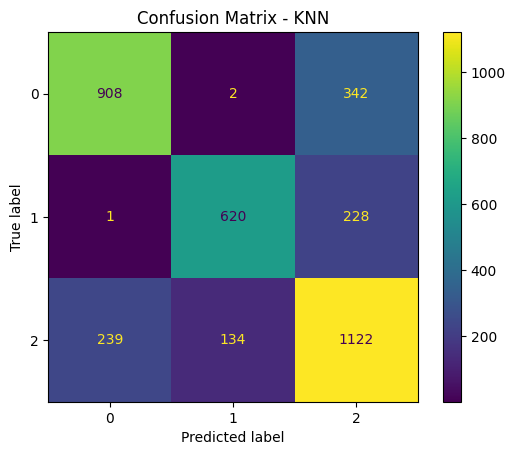

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

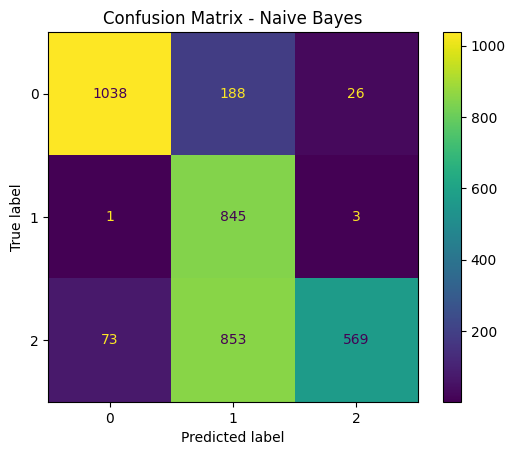

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_naive)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

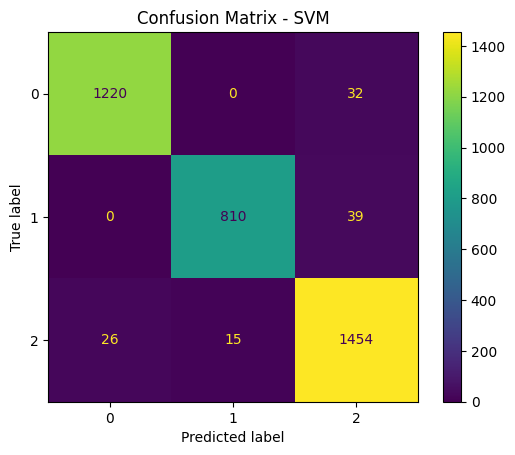

In [125]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

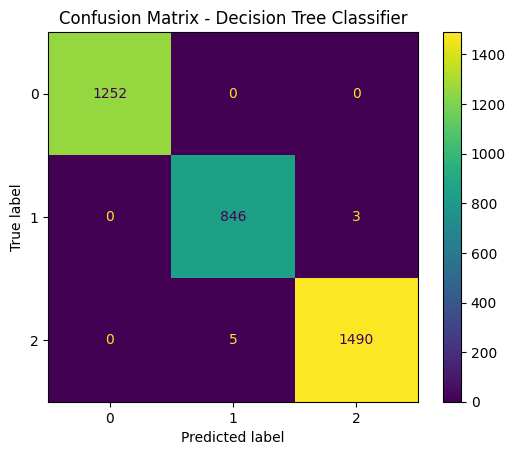

In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.show()

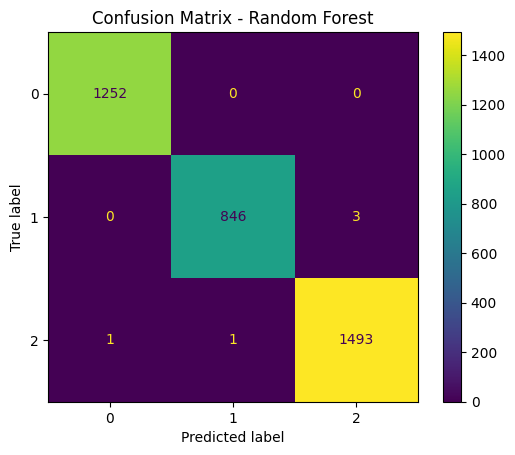

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_random)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [154]:
new_sample = [[26,2,6,0,7,6.0,6,7,5.3,77.5,5.31,4.9,0,0,1,0,1,0]]
new_sample_scaled = scaler.transform(new_sample)
pred = model_RT.predict(new_sample_scaled)
print("Predicted productivity cluster:", pred[0])

Predicted productivity cluster: 1


In [155]:
cluster_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

print("Predicted Productivity:", cluster_map[pred[0]])

Predicted Productivity: Medium


In [156]:
import pickle

artifact = {
    "model": model_RT,
    "features": x.columns.tolist()
}

with open("productivity_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

In [ ]:
#np.isnan(x_train).sum()

In [ ]:
#np.isnan(x_test).sum()

In [ ]:
#import pandas as pd 
#pd.Series(np.isnan(x_train).sum(axis=0)).sort_values(ascending=False)

In [ ]:
#x.columns[18]

In [144]:
x.columns

Index(['cycle_length_days', 'flow_level', 'pain_level', 'pms_symptoms',
       'mood_score', 'stress_score_cycle', 'energy_level',
       'concentration_score', 'work_hours_lost', 'estrogen_pgml',
       'progesterone_ngml', 'sleep_hours', 'pcos_diagnosed',
       'cycle_phase_Follicular', 'cycle_phase_Luteal', 'cycle_phase_Menstrual',
       'ovulation_result_Negative', 'ovulation_result_Positive'],
      dtype='object')

In [147]:
len(x.columns)

18

In [145]:
x.tail()

,cycle_length_days,flow_level,pain_level,pms_symptoms,mood_score,stress_score_cycle,energy_level,concentration_score,work_hours_lost,estrogen_pgml,progesterone_ngml,sleep_hours,pcos_diagnosed,cycle_phase_Follicular,cycle_phase_Luteal,cycle_phase_Menstrual,ovulation_result_Negative,ovulation_result_Positive
17971,26,2,6,0,7,6.0,6,7,5.3,77.5,5.31,4.9,0,0,1,0,1,0
17972,27,2,6,1,7,8.2,8,6,3.0,65.5,0.74,4.9,0,0,0,1,0,1
17973,30,2,6,0,5,7.6,6,7,4.6,51.9,1.26,4.9,0,0,0,1,1,0
17974,29,1,3,0,8,7.2,6,8,3.0,85.3,8.99,4.9,0,0,1,0,0,1
17975,27,2,4,1,8,6.8,7,9,3.7,109.1,2.17,4.9,0,1,0,0,1,0
